In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data_cleaned.csv")

## Some basic information

In [40]:
print("Columns:", df.columns.tolist())
print(df.head())
print(df.info())

Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
         Date       Open       High        Low      Close   Volume
0  1957-03-04  44.060001  44.060001  44.060001  44.060001  1890000
1  1957-03-05  44.220001  44.220001  44.220001  44.220001  1860000
2  1957-03-06  44.230000  44.230000  44.230000  44.230000  1840000
3  1957-03-07  44.209999  44.209999  44.209999  44.209999  1830000
4  1957-03-08  44.070000  44.070000  44.070000  44.070000  1630000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16031 entries, 0 to 16030
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    16031 non-null  object 
 1   Open    16031 non-null  float64
 2   High    16031 non-null  float64
 3   Low     16031 non-null  float64
 4   Close   16031 non-null  float64
 5   Volume  16031 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 751.6+ KB
None


convert "Date" to date type

In [41]:
df["Date"] = pd.to_datetime(df["Date"])

## Exploratory Data Analysis

Close price plot

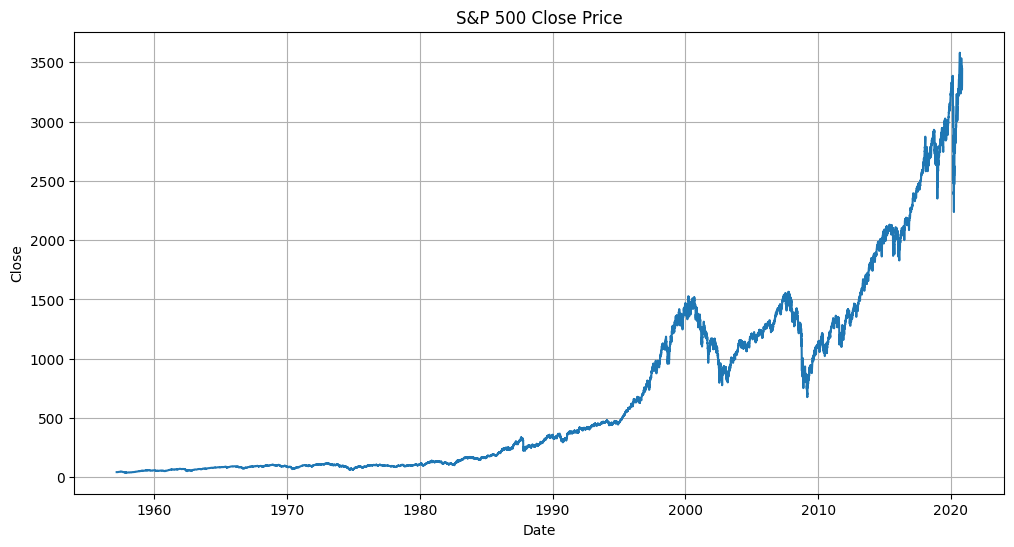

In [42]:
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"])
plt.title("S&P 500 Close Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.show()

We noticed some significant drawdown  
1987 black monday  
2000 - 2003 911 + 互联网泡沫破裂 + 企业丑闻  
2007 - 2009 金融危机  
2019 - 2020 covid-19

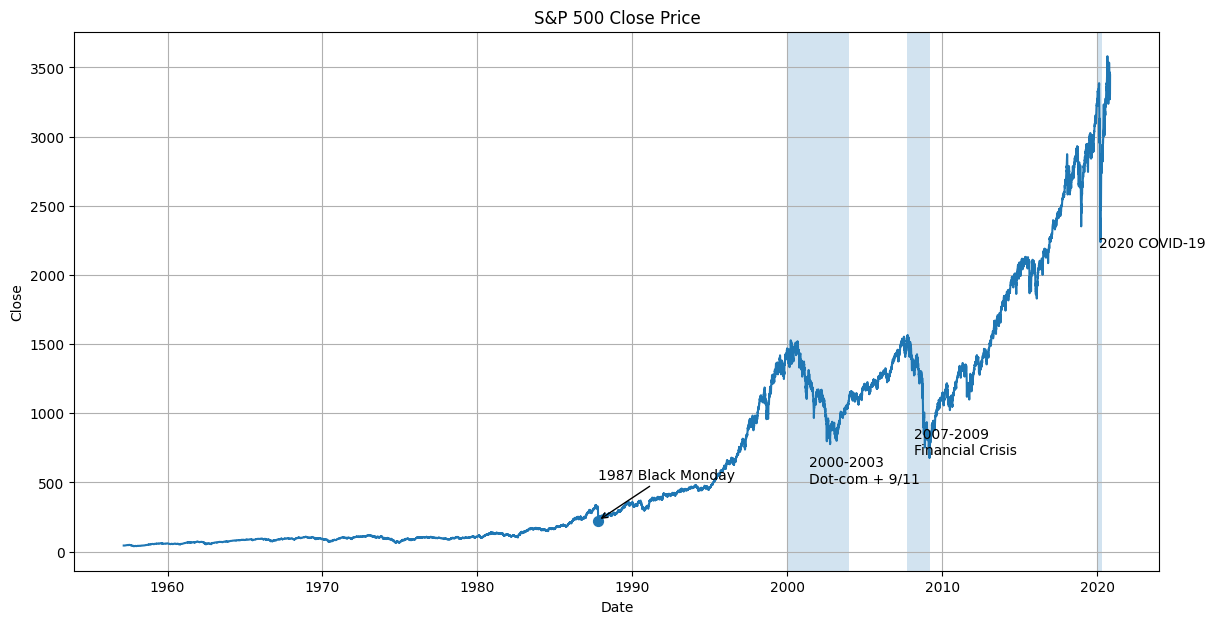

In [43]:
import matplotlib.pyplot as plt
import pandas as pd


fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df["Date"], df["Close"])
ax.set_title("S&P 500 Close Price")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.grid(True)

# ---------- 1. 单个事件：1987 Black Monday ----------
date_1987 = pd.to_datetime("1987-10-19")
y_1987 = df.loc[df["Date"] == date_1987, "Close"]

if not y_1987.empty:
    y_1987 = y_1987.iloc[0]
    ax.scatter(date_1987, y_1987, s=50)
    ax.annotate("1987 Black Monday",
                xy=(date_1987, y_1987),
                xytext=(date_1987, y_1987 + 300),
                arrowprops=dict(arrowstyle="->"))

# ---------- 2. 区间：2000–2003 ----------
ax.axvspan(pd.to_datetime("2000-01-01"),
           pd.to_datetime("2003-12-31"),
           alpha=0.2)
ax.text(pd.to_datetime("2001-06-01"), 500, "2000-2003\nDot-com + 9/11", fontsize=10)

# ---------- 3. 区间：2007–2009 ----------
ax.axvspan(pd.to_datetime("2007-10-01"),
           pd.to_datetime("2009-03-31"),
           alpha=0.2)
ax.text(pd.to_datetime("2008-03-01"), 700, "2007-2009\nFinancial Crisis", fontsize=10)

# ---------- 4. 区间：2019–2020 COVID ----------
ax.axvspan(pd.to_datetime("2020-02-01"),
           pd.to_datetime("2020-04-30"),
           alpha=0.2)
ax.text(pd.to_datetime("2020-02-15"), 2200, "2020 COVID-19", fontsize=10)

plt.show()

### Correlation

In [44]:
corr_cols = ["Open", "High", "Low", "Close", "Volume"]
corr_matrix = df[corr_cols].corr()
print(corr_matrix)

            Open      High       Low     Close    Volume
Open    1.000000  0.999965  0.999947  0.999914  0.792757
High    0.999965  1.000000  0.999928  0.999954  0.793854
Low     0.999947  0.999928  1.000000  0.999958  0.791198
Close   0.999914  0.999954  0.999958  1.000000  0.792504
Volume  0.792757  0.793854  0.791198  0.792504  1.000000


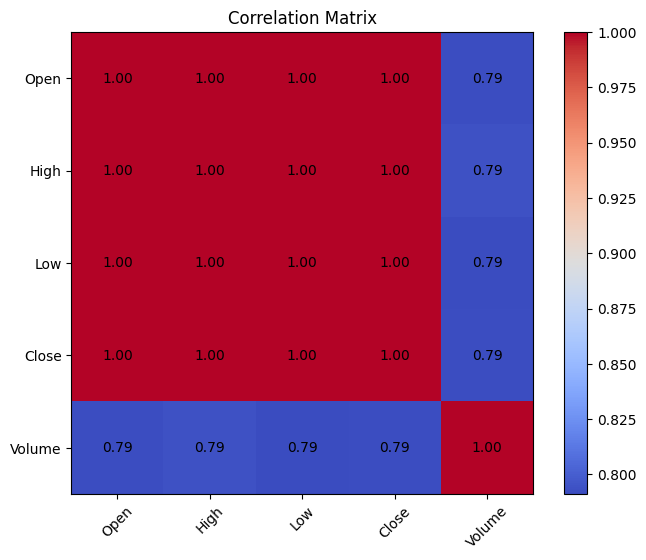

In [45]:
import numpy as np

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Correlation Matrix")
plt.show()

我们发现open/high/low/close 之间强相关，volumn也是  
可能是因为同一天内的数据必然相关  
因此我们引入return  
这里的Close Return 为传统意义的daily return  
这里可以引用文献解释为什么daily return有意义，但是也可以不解释直接放daily return因为属于金融常识  

### Daily Return = $\frac{P_t - P_{t-1}}{P_{t-1}}$

In [48]:
df["openReturn"] = df["Open"].pct_change()
df["highReturn"] = df["High"].pct_change()
df["lowReturn"] = df["Low"].pct_change()
df["closeReturn"] = df["Close"].pct_change() ## Same as "Daily Return"
df["volumeChange"] = df["Volume"].pct_change()

corr_cols = [
    "openReturn", "highReturn", "lowReturn",
    "closeReturn", "volumeChange"
]

corr_matrix = df[corr_cols].corr()
print(corr_matrix)

              openReturn  highReturn  lowReturn  closeReturn  volumeChange
openReturn      1.000000    0.642519   0.631650     0.104730     -0.003670
highReturn      0.642519    1.000000   0.726330     0.626786      0.127702
lowReturn       0.631650    0.726330   1.000000     0.647028     -0.053109
closeReturn     0.104730    0.626786   0.647028     1.000000      0.032595
volumeChange   -0.003670    0.127702  -0.053109     0.032595      1.000000


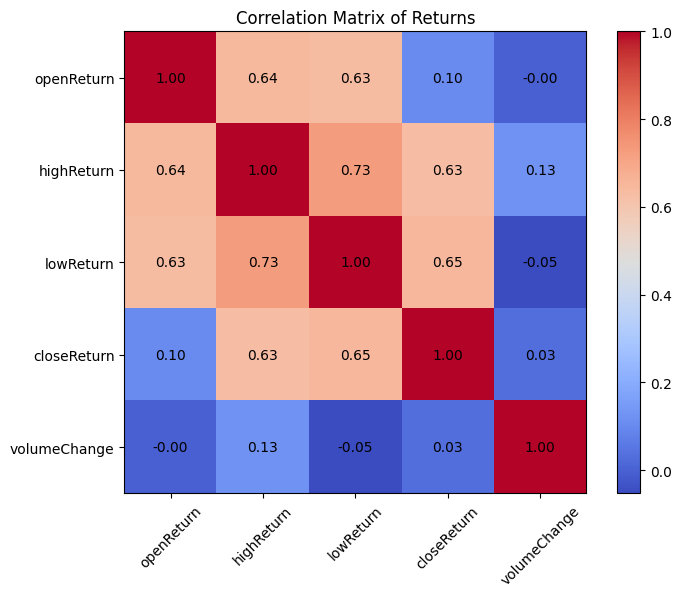

In [49]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Correlation Matrix of Returns")
plt.show()

Looks good!

发现开盘价和收盘价的关系不大  
volume和价格关系不大 说明怎么样都有大冤种  
close return和high/low return高度相关 - 收盘价和当天价格区间变化有关

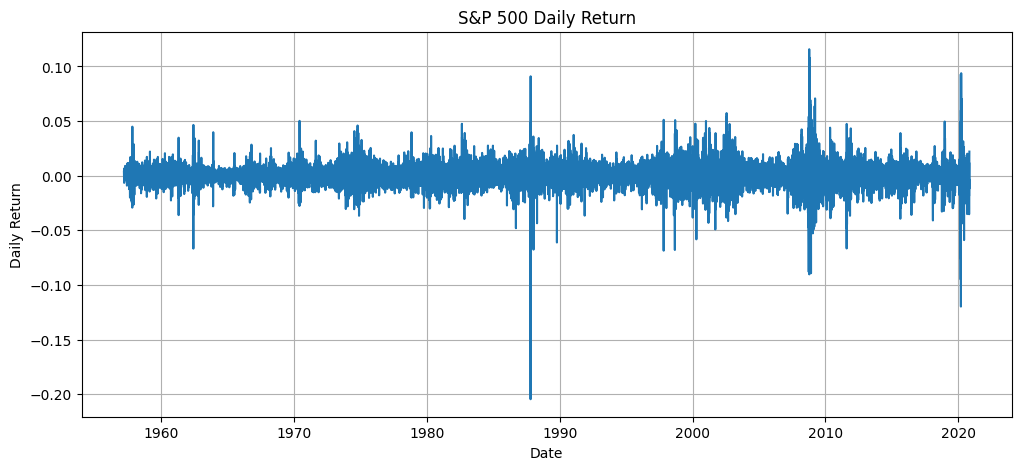

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["closeReturn"])
plt.title("S&P 500 Daily Return")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

add important events

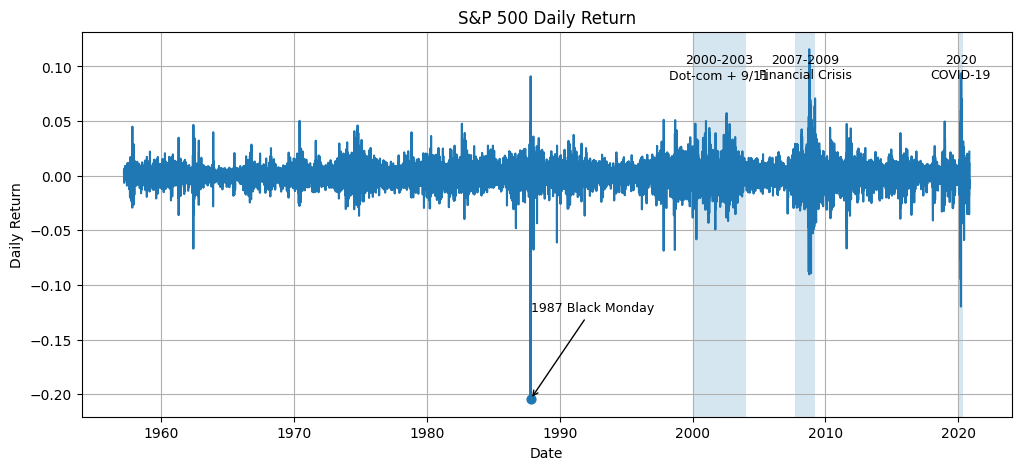

In [52]:
import matplotlib.pyplot as plt
import pandas as pd

df["Date"] = pd.to_datetime(df["Date"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["Date"], df["closeReturn"])

ax.set_title("S&P 500 Daily Return")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return")
ax.grid(True)

ymin, ymax = ax.get_ylim()
text_y = ymax * 0.75   # 文字放在上方一点

# ---------- 区间事件 ----------
events = [
    ("2000-01-01", "2003-12-31", "2000-2003\nDot-com + 9/11"),
    ("2007-10-01", "2009-03-31", "2007-2009\nFinancial Crisis"),
    ("2020-02-01", "2020-04-30", "2020\nCOVID-19")
]

for start, end, label in events:
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    ax.axvspan(start, end, alpha=0.18)

    mid = start + (end - start) / 2
    ax.text(mid, text_y, label, ha="center", va="center", fontsize=9)

# ---------- 单点事件：1987 Black Monday ----------
date_1987 = pd.to_datetime("1987-10-19")

# 找最接近 1987-10-19 的那一天
idx = (df["Date"] - date_1987).abs().idxmin()
x_1987 = df.loc[idx, "Date"]
y_1987 = df.loc[idx, "closeReturn"]

ax.scatter(x_1987, y_1987, s=40)
ax.annotate(
    "1987 Black Monday",
    xy=(x_1987, y_1987),
    xytext=(x_1987, y_1987 + 0.08),
    arrowprops=dict(arrowstyle="->"),
    fontsize=9
)

plt.show()

### Daily Return Distribution

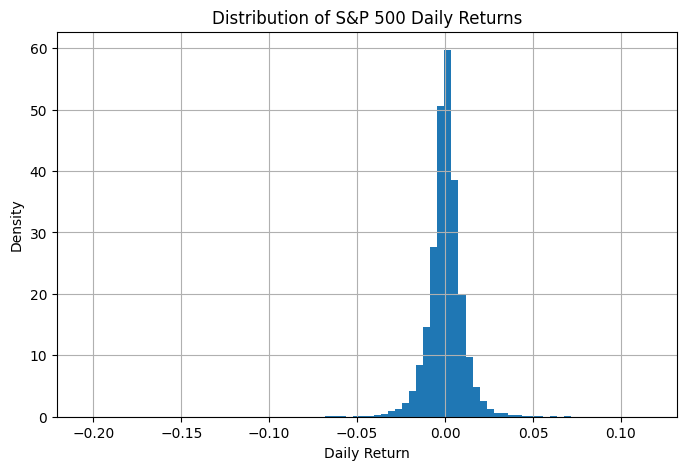

In [53]:
plt.figure(figsize=(8, 5))
plt.hist(df["closeReturn"].dropna(), bins=80, density=True)
plt.title("Distribution of S&P 500 Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.grid(True)
plt.show()

中心在0 大多数涨跌幅度都很小  
极端下跌比极端上升严重  
heavy tails 极端值多 （左右尾巴长

### 30-day rolling volatility

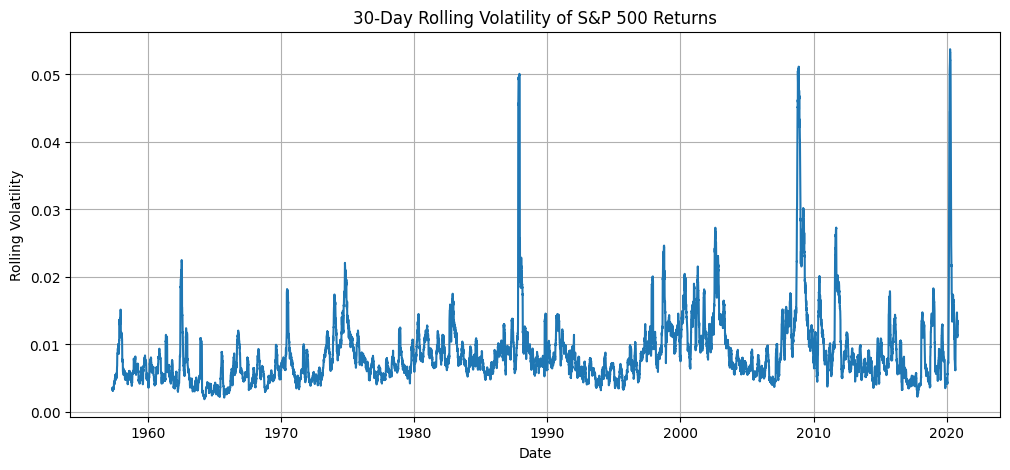

In [54]:
df["rollingVolatility"] = df["closeReturn"].rolling(window=30).std()

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["rollingVolatility"])
plt.title("30-Day Rolling Volatility of S&P 500 Returns")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.grid(True)
plt.show()

市场不稳定 波动率上下浮动  
volatility clustering 波动聚集 高波动会持续多天 不是只有一个点  
几个spike正好对应几个events

### ACF of daily returns

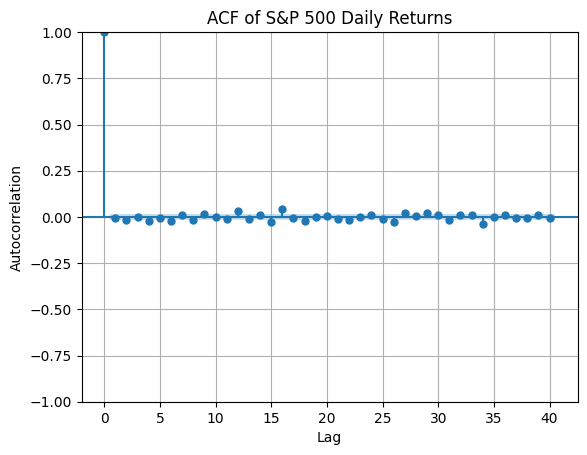

In [55]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(df["closeReturn"].dropna(), lags=40)
plt.title("ACF of S&P 500 Daily Returns")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

daily return 没有自相关，即过去的daily return几乎不影响今天的return

### ACF of squared return

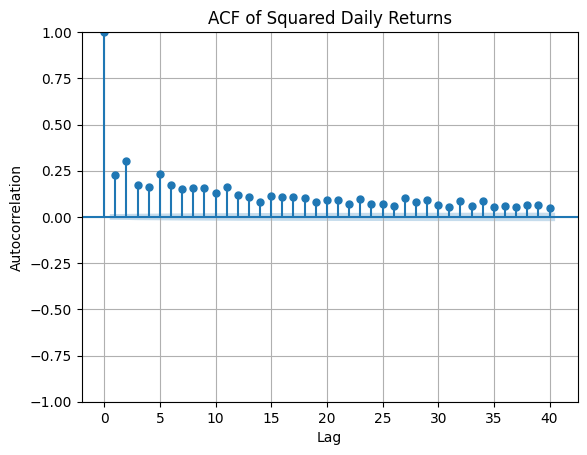

In [56]:
plot_acf(df["closeReturn"].dropna() ** 2, lags=40)
plt.title("ACF of Squared Daily Returns")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

squared return是volatility的替代指标  
不直接用volatility是因为计算时候取了一定的Windows 因此一定会有记忆性

波动大小是有持续性的  
今天如果市场波动很大，接下来几天也更可能继续高波动  
今天如果市场很平静，接下来几天也更可能继续低波动  
即验证了存在 volatility clustering